# Segments

Where the model works and for whom. Risk deciles and cumulative default capture show ranking quality; subgroup AUC checks it holds across age, income, and gender.

In [1]:
import sys; sys.path.append("..")
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from src.data import RAW

INTERIM = Path("../data/interim")
p = pd.read_pickle(INTERIM / "predictions.pkl")["lgb_bag"].rename("p_default")
app = pd.read_csv(RAW / "application_train.csv",
                  usecols=["SK_ID_CURR", "TARGET", "CODE_GENDER", "DAYS_BIRTH", "AMT_INCOME_TOTAL"]).set_index("SK_ID_CURR")
df = app.join(p).dropna(subset=["p_default"])
y = df["TARGET"]
df["age"] = (-df["DAYS_BIRTH"] / 365).round()
df.shape

(307511, 6)

## Risk deciles

In [2]:
df["decile"] = pd.qcut(df["p_default"], 10, labels=False)
df.groupby("decile").agg(avg_p=("p_default", "mean"), default_rate=("TARGET", "mean"), n=("TARGET", "size")).round(4)

,avg_p,default_rate,n
decile,,,
0,0.0086,0.0071,30752
1,0.0146,0.0138,30751
2,0.0204,0.0212,30751
3,0.0271,0.0274,30751
4,0.0358,0.0392,30751
5,0.0476,0.0527,30751
6,0.0649,0.0717,30751
7,0.0923,0.1039,30751
8,0.1426,0.1551,30751


## Cumulative default capture

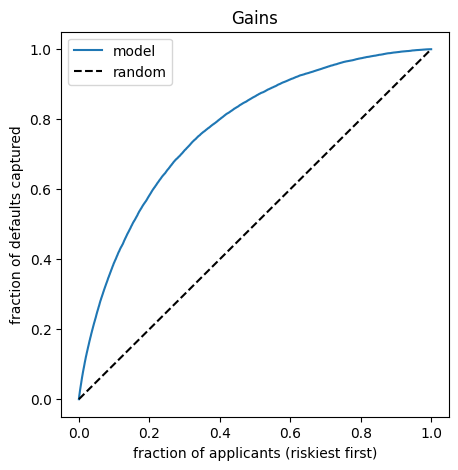

In [3]:
order = df.sort_values("p_default", ascending=False)
cum = order["TARGET"].cumsum() / order["TARGET"].sum()
frac = np.arange(1, len(order) + 1) / len(order)
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(frac, cum.values, label="model")
ax.plot([0, 1], [0, 1], "k--", label="random")
ax.set(xlabel="fraction of applicants (riskiest first)", ylabel="fraction of defaults captured", title="Gains")
ax.legend(); plt.show()

## Subgroup AUC

In [4]:
def sub_auc(mask):
    return round(roc_auc_score(y[mask], df["p_default"][mask]), 4) if y[mask].nunique() == 2 else np.nan

df["age_band"] = pd.cut(df["age"], [0, 30, 40, 50, 60, 100])
df["income_band"] = pd.qcut(df["AMT_INCOME_TOTAL"], 4, labels=["Q1", "Q2", "Q3", "Q4"])
rows = []
for g in ["M", "F"]:
    rows.append({"segment": f"gender={g}", "n": int((df.CODE_GENDER == g).sum()), "auc": sub_auc(df.CODE_GENDER == g)})
for b in df["age_band"].cat.categories:
    rows.append({"segment": f"age={b}", "n": int((df.age_band == b).sum()), "auc": sub_auc(df.age_band == b)})
for b in ["Q1", "Q2", "Q3", "Q4"]:
    rows.append({"segment": f"income={b}", "n": int((df.income_band == b).sum()), "auc": sub_auc(df.income_band == b)})
pd.DataFrame(rows)

,segment,n,auc
0,gender=M,105059,0.7879
1,gender=F,202448,0.7964
2,"age=(0, 30]",48869,0.7706
3,"age=(30, 40]",82770,0.7972
4,"age=(40, 50]",75509,0.8018
5,"age=(50, 60]",67955,0.7906
6,"age=(60, 100]",32408,0.7571
7,income=Q1,100578,0.7978
8,income=Q2,53182,0.7955
9,income=Q3,82213,0.7945
